In [ ]:
import os
import re
import time
import random
import requests
import pandas as pd
import json
import threading
 
from pathlib import Path
from pydantic import BaseModel, Field

from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from openai import OpenAI
from typing import List, Dict, Any


df = pd.read_csv('rna_seq_data/rna_seq_gds_with_publication_filtered.csv')

total_unique_pmc_ids = set(df['pmcids'].str.split(";").explode())

print(f"We have a total of {len(df)} GSE accessions.")
print(f"We have a total of {len(total_unique_pmc_ids)} unique PMCIDs.")

data_dir = Path("rna_seq_data/bioCjson_raw")
file_paths = sorted([p for p in data_dir.iterdir() if p.is_file()])

print(f"\nWe retrieved a total of {len(file_paths)} full texts in BioC JSON format.")


We have a total of 10771 GSE accessions.
We have a total of 8501 unique PMCIDs.

We retrieved a total of 7647 full texts in BioC JSON format.


# First, we mush fetch GSE text summaries. The code in the cell below is vibe coded. :) 

In [2]:

def _one_line(text):
    if text is None:
        return None
    text = str(text).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


def _parse_series_fields_from_text(text: str):
    title_vals = []
    summary_vals = []
    overall_design_vals = []

    for line in text.splitlines():
        if line.startswith("!Series_title"):
            title_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")
        elif line.startswith("!Series_summary"):
            summary_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")
        elif line.startswith("!Series_overall_design"):
            overall_design_vals.append(line.split("=", 1)[1].strip() if "=" in line else "")

    title = _one_line(" ".join(v for v in title_vals if v))
    summary = _one_line(" ".join(v for v in summary_vals if v))
    overall_design = _one_line(" ".join(v for v in overall_design_vals if v))

    return title, summary, overall_design


def _append_batch_to_csv(batch_rows, output_path):
    if not batch_rows:
        return
    batch_df = pd.DataFrame(batch_rows)
    write_header = not os.path.exists(output_path)
    batch_df.to_csv(output_path, mode="a", header=write_header, index=False)


def fetch_gse_text_summaries_fast(
    gse_ids,
    output_path="rna_seq_data/gse_text_summaries.csv",
    batch_size=500,
    sleep_sec=0.03,
    timeout=30,
    max_workers=6,
):
    session = requests.Session()

    retries = Retry(
        total=3,
        connect=3,
        read=3,
        backoff_factor=0.5,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=["GET"],
    )
    adapter = HTTPAdapter(
        pool_connections=max_workers * 2,
        pool_maxsize=max_workers * 2,
        max_retries=retries,
    )
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    processed = set()
    if os.path.exists(output_path):
        existing_df = pd.read_csv(output_path, dtype={"accession": str}, keep_default_na=False)
        if "accession" in existing_df.columns:
            processed = set(existing_df["accession"].astype(str).str.strip())
        print(f"Resuming: found {len(processed)} already saved accessions.")

    gse_ids = [str(g).strip() for g in gse_ids if str(g).strip()]
    pending_ids = [g for g in gse_ids if g not in processed]
    print(f"Total input: {len(gse_ids)} | Pending: {len(pending_ids)}")

    def _fetch_one(gse):
        params = {
            "acc": gse,
            "targ": "self",
            "form": "text",
            "view": "quick",
        }

        r = session.get(
            "https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi",
            params=params,
            timeout=timeout,
        )
        r.raise_for_status()

        title, summary, overall_design = _parse_series_fields_from_text(r.text)
        text_summary = _one_line(" ".join(x for x in [title, summary, overall_design] if x))

        delay = random.uniform(max(0.005, sleep_sec * 0.6), max(0.02, sleep_sec * 1.8))
        time.sleep(delay)

        return {
            "accession": gse,
            "title": title,
            "summary": summary,
            "overall_design": overall_design,
            "text_summary": text_summary,
        }

    batch_rows = []
    done = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_gse = {executor.submit(_fetch_one, gse): gse for gse in pending_ids}

        for future in as_completed(future_to_gse):
            gse = future_to_gse[future]
            try:
                row = future.result()
                batch_rows.append(row)
                done += 1
            except Exception as e:
                print(f"{gse}: failed ({e})")
                continue

            if len(batch_rows) >= batch_size:
                _append_batch_to_csv(batch_rows, output_path)
                print(f"Saved checkpoint: {done}/{len(pending_ids)} new accessions")
                batch_rows = []

    _append_batch_to_csv(batch_rows, output_path)

    if pending_ids:
        print(f"Done. Saved up to {len(pending_ids)} new rows to {output_path}")

    final_df = pd.read_csv(output_path, dtype={"accession": str}) if os.path.exists(output_path) else pd.DataFrame()
    return final_df


# Run fast fetch
gse_ids = df["accession"].dropna().astype(str).str.strip().unique().tolist()
meta_df = fetch_gse_text_summaries_fast(
    gse_ids,
    output_path="rna_seq_data/gse_text_summaries.csv",
    batch_size=500,
    sleep_sec=0.03,
    max_workers=6,
)

# meta_df.iloc[0].to_dict()

Resuming: found 10771 already saved accessions.
Total input: 10771 | Pending: 0


# Now we have all the data to build the prompts into a single JSONL file.

In [3]:
SYSTEM_PROMPT = """**System Role:**
You are an expert computational biologist and bioinformatics data curator. Your task is to analyze the provided GEO Title, Summary, and Overall Design and accurately classify the *source context* of the RNA-seq/transcriptomic data.

**Objective:**
Determine whether the dataset consists of:
1) **DIRECT CLINICAL BIOSPECIMENS** (i.e., directly collected from humans in a cohort/clinical/research setting),
2) **LABORATORY / EXPERIMENTAL MODELS** (i.e., any engineered/cultured/model system), or
3) **INSUFFICIENT DATA** to tell.

**Important Warnings:**
- Do NOT rely on the "Organism: Homo sapiens" tag. Human cell lines, organoids, and human cells implanted into mice (xenografts) are tagged as "Homo sapiens" but are laboratory models, not direct clinical biospecimens.
- “Human donor” ≠ “clinical biospecimen” by default. If cells/tissues are *cultured, stimulated, expanded, differentiated, engineered,* or *grown in animals*, classify as LAB MODEL.

---
## Classification Criteria

### 1) LABORATORY / EXPERIMENTAL MODEL (Classify as: LAB MODEL)
Classify as LAB MODEL if the RNA comes from any experimental system, including:

- **Cell lines:** Established immortalized lines (e.g., HeLa, MCF7, A549, HEK293, HCT116, K562).
- **In vitro culture / stimulation / expansion:** Mentions such as “cultured”, “passaged”, “expanded”, “activated”, “stimulated”, “incubated”, “seeded”, “treated in vitro”, “co-culture”, “time course in culture”.
- **Ex vivo / 3D models:** “organoids”, “tumor spheres”, “primary cell culture”, “iPSC-derived”, “differentiated in vitro”, “air-liquid interface”, “Matrigel”.
- **Genetic engineering / perturbation:** CRISPR/Cas9, knockout (KO), knockdown (KD), siRNA/shRNA, gRNA, lentivirus/viral transduction, plasmids, overexpression, electroporation, RNPs.
- **Animal models / xenografts:** mice/murine, in vivo, immunodeficient, xenograft, CDX, PDX.
  - Note: If the biospecimen was grown/propagated in an animal (including PDX), it is a LAB MODEL.

### 2) DIRECT CLINICAL BIOSPECIMEN (Classify as: CLINICAL SPECIMEN)
Classify as CLINICAL SPECIMEN if the RNA is taken directly from human subjects (patients or healthy volunteers) as collected samples, without being turned into a sustained experimental model.

Strong indicators:
- **Clinical sample types:** “biopsy”, “surgical resection”, “primary tumor”, “adjacent normal”, “blood”, “plasma”, “serum”, “PBMC” (when directly processed), “FFPE”, “pathology”.
- **Cohort/clinical framing:** “patients”, “healthy volunteers”, “clinical cohort”, “case-control”, “prospective/retrospective cohort”, “clinical trial phase I/II/III”.
- **Ethics/privacy:** “informed consent”, “IRB”, “ethics committee approval”, “patient privacy”.
- **Clinical metadata:** stage/grade, response, survival, recurrence, treatment regimen.

Important boundary rule:
- If PBMC/T cells/etc. are collected from humans BUT then **activated/expanded/cultured/engineered** (e.g., CAR-T generation), classify as **LAB MODEL**.

### 3) INSUFFICIENT / VAGUE DATA (Classify as: UNCLEAR)
Use ONLY if the metadata does not provide enough information to decide between CLINICAL SPECIMEN vs LAB MODEL.

---

## Output (STRICT)
Return ONLY a JSON object with:

```json
{
  "classification": "LAB MODEL, CLINICAL SPECIMEN, or UNCLEAR",
  "evidence": [
    "Quote 1",
    "Quote 2"
  ],
  "reasoning": "1-2 sentences explaining why those phrases dictate the classification."
}
```
---
## Examples

**EXAMPLE 1 (LAB MODEL):**
Input: RNA-seq of a colorectal cancer cell line (HCT116)... clonal HCT116 lines that stably express Cas9... xenografts (CDXs) engrafted into two immunodeficient mice.
Output:
```json
{
  "classification": "LAB MODEL",
  "evidence": [
    "colorectal cancer cell line (HCT116)",
    "express Cas9",
    "xenografts (CDXs) engrafted into two immunodeficient mice"
  ],
  "reasoning": "The data is from an immortalized cell line with CRISPR-related engineering and includes an in vivo mouse xenograft model."
}
```

**EXAMPLE 2 (CLINICAL SPECIMEN):**
Input: Lung cancer tissues were taken from 61 patients... informed written consent... FFPE tumour tissue.
Output:
```json
{
  "classification": "CLINICAL SPECIMEN",
  "evidence": [
    "taken from 61 patients",
    "informed written consent",
    "formalin fixed, paraffin embedded (FFPE) tumour tissue"
  ],
  "reasoning": "These are directly collected human clinical samples with consent and standard pathology storage (FFPE)."
}
```

**EXAMPLE 3 (CLINICAL SPECIMEN):**
Input: patients recruited to a clinical phase I/II trial... associated with progression-free and overall survival.
Output:
```json
{
  "classification": "CLINICAL SPECIMEN",
  "evidence": [
    "patients recruited to a clinical phase I/II trial",
    "associated with improved progression-free and overall survival"
  ],
  "reasoning": "The transcriptomes come from human trial participants and are linked to clinical outcomes."
}
```

**EXAMPLE 4 (LAB MODEL):**
Input: patient-derived organoid lines... trypsinized, plated in matrigel... After 14 days of plating.
Output:
```json
{
  "classification": "LAB MODEL",
  "evidence": [
    "patient-derived organoid lines",
    "plated in matrigel",
    "After 14 days of plating"
  ],
  "reasoning": "Although originating from patients, the RNA-seq was generated from organoids maintained and grown in vitro."
}
```

**EXAMPLE 5 (LAB MODEL):**
Input: CRISPR screen in A549 cells... knockout cells generated by CRISPR deletion.
Output:
```json
{
  "classification": "LAB MODEL",
  "evidence": [
    "CRISPR screen in A549 cells",
    "knockout cells were generated by CRISPR deletion"
  ],
  "reasoning": "An established cell line was genetically engineered via CRISPR, which is an experimental lab model."
}
```

**EXAMPLE 6 (CLINICAL SPECIMEN):**
Input: obtained fresh surgical resections from ... patients ... and eleven PDX models ... fresh tumour biopsies from treating centers ... ages ranged from 3-17 years.
Output:
```json
{
  "classification": "CLINICAL SPECIMEN",
  "evidence": [
    "fresh surgical resections from ... patients",
    "fresh tumour biopsies from ... treating centers",
    "ages ranged from 3-17 years"
  ],
  "reasoning": "Despite mentioning PDXs, the dataset includes directly obtained patient biopsies/resections with clinical cohort metadata."
}
```

**EXAMPLE 7 (UNCLEAR):**
Input: RNA-seq of control and treated samples... response to compound XYZ-123... 3 control replicates and 3 treated replicates.
Output:
```json
{
  "classification": "UNCLEAR",
  "evidence": [
    "RNA-seq of control and treated samples",
    "transcriptomic changes in response to the novel compound XYZ-123"
  ],
  "reasoning": "The metadata does not specify the biological source (tissue/cell type) or whether it is a direct clinical biospecimen or an experimental model."
}
```"""

USER_PROMPT = "Now, analyze the following GEO dataset:\n Title: {}\n Summary: {}\n Overall design: {}"

combined_df = df.merge(meta_df, left_on="accession", right_on="accession", how="left")

input_prompts = []
for row in combined_df.itertuples():

    # Store as a list of messages (standard chat format)
    input_prompts.append({
        "gseid": row.accession,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_PROMPT.format(row.title, row.summary, row.overall_design)}
        ]
    })


with open("rna_seq_data/transcriptomic-source-classification-prompts.jsonl", "w") as f:
    for prompt in input_prompts:
        f.write(json.dumps(prompt) + "\n")



In [4]:
import statistics
import tiktoken

prompts_path = "rna_seq_data/transcriptomic-source-classification-prompts.jsonl"
enc = tiktoken.get_encoding("o200k_base")

user_token_counts = []

with open(prompts_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        user_text = "\n".join(
            str(m.get("content", ""))
            for m in item.get("messages", [])
            if m.get("role") == "user"
        )

        user_token_counts.append(len(enc.encode(user_text)))

total_prompts = len(user_token_counts)
total_user_tokens = sum(user_token_counts)
mean_tokens = statistics.mean(user_token_counts) if user_token_counts else 0
median_tokens = statistics.median(user_token_counts) if user_token_counts else 0

system_prompt_text = SYSTEM_PROMPT if "SYSTEM_PROMPT" in globals() else ""
system_prompt_tokens_single = len(enc.encode(system_prompt_text)) if system_prompt_text else 0
total_system_tokens = system_prompt_tokens_single * total_prompts

print(f"Tokenizer: {enc.name}")
print(f"Total prompts: {total_prompts}")
print(f"Total user tokens: {total_user_tokens:,}")
print(f"Average user tokens per prompt: {mean_tokens:.2f}")
print(f"Median user tokens per prompt: {median_tokens:.2f}")
print(f"System prompt tokens (single): {system_prompt_tokens_single:,}")
print(f"Total system tokens (reused across all prompts): {total_system_tokens:,}")

Tokenizer: o200k_base
Total prompts: 10771
Total user tokens: 2,793,088
Average user tokens per prompt: 259.32
Median user tokens per prompt: 230.00
System prompt tokens (single): 1,767
Total system tokens (reused across all prompts): 19,032,357


In [ ]:
class ClassificationResponse(BaseModel):
    """Structured output schema for transcriptomic source classification."""
    classification: str = Field(description="LAB MODEL, PATIENT DATA, or UNCLEAR")
    evidence: List[str] = Field(description="Direct quotes from the text that support the classification.")
    reasoning: str = Field(description="1-2 sentences explaining why those phrases dictate the classification.")


# OpenAI reads OPENAI_API_KEY from the environment.
client = OpenAI()

def _call_openai(messages: List[Dict[str, Any]]) -> Any:
    # Responses API uses "input" + "input_text" content type
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": [{"type": "input_text", "text": msg["content"]}],
        })

    # client.responses.parse is the correct method for:
    # - structured output (text_format param)
    # - reasoning effort
    # - input_text content type
    resp = client.responses.parse(
        model="gpt-5.2-2025-12-11",
        input=formatted_messages,
        text_format=ClassificationResponse,  # Pydantic model for structured output
        reasoning={"effort": "low"},
        service_tier="flex"
    )

    # Result is accessed via resp.output_parsed, not resp.choices[0]
    return resp.output_parsed, resp.usage


def _call_openrouter(messages: List[Dict[str, Any]]) -> Any:
    # IMPORTANT: Use standard create(), not responses.parse() for OSS models
    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        # To force DeepInfra and ensure consistent pricing:
        extra_body={
            "provider": {
                "order": ["DeepInfra"],
                "allow_fallbacks": False
            },
            # Since we can't use 'text_format', we use 'response_format'
            "response_format": {"type": "json_object"}
        }
    )

    content = resp.choices[0].message.content
    if not isinstance(content, str):
        raise TypeError(f"Expected JSON string content, got {type(content).__name__}")

    content = content.strip()
    if not content:
        raise ValueError("OpenRouter returned empty content")

    parsed = ClassificationResponse.model_validate_json(content)

    usage = resp.usage
    input_tokens = getattr(usage, "input_tokens", None)
    if input_tokens is None:
        input_tokens = getattr(usage, "prompt_tokens", None)

    output_tokens = getattr(usage, "output_tokens", None)
    if output_tokens is None:
        output_tokens = getattr(usage, "completion_tokens", None)

    token_details = getattr(usage, "input_tokens_details", None)
    if token_details is None:
        token_details = getattr(usage, "prompt_tokens_details", None)

    usage_details = {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cached_tokens": getattr(token_details, "cached_tokens", None) if token_details is not None else None,
        "total_tokens": getattr(usage, "total_tokens", None),
    }

    return parsed, usage_details



input_prompts = []
with open("rna_seq_data/transcriptomic-source-classification-prompts.jsonl", "r") as f:
    for line in f:
        if line.strip():
            input_prompts.append(json.loads(line))

results_file = "rna_seq_data/transcriptomic-source-classification-results-5.2.jsonl"
computed_gseids = set()

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            result_data = json.loads(line)
            computed_gseids.add(str(result_data.get("gseid")).strip())

pending_prompts = [
    p for p in input_prompts
    if p.get("gseid") not in computed_gseids
]

# to recompute total_gseids
# pending_prompts = [
#     p for p in input_prompts
#     if p.get("gseid") in total_gseids
# ]

print(f"Found {len(computed_gseids)} already computed submissions")
print(f"Processing {len(pending_prompts)} remaining submissions")

# raise Exception("Stop here")

MAX_WORKERS = 12
write_lock = threading.Lock()


def _worker(prompt_data, file_handle):
    gseid = prompt_data["gseid"]
    messages = prompt_data["messages"]

    try:
        parsed, usage = _call_openai(messages)
        # parsed, usage = _call_openrouter(messages)  # For OpenRouter, use this line instead
        usage_data = usage.model_dump() if hasattr(usage, "model_dump") else usage
        result_data = {
            "gseid": gseid,
            "response": parsed.model_dump(),
            "usage": usage_data,
        }

        line = json.dumps(result_data, ensure_ascii=False) + "\n"
        with write_lock:
            file_handle.write(line)
            file_handle.flush()

        return {"ok": True, "gseid": gseid}
    except Exception as e:
        return {"ok": False, "gseid": gseid, "error": str(e)}

results_count = 0
error_count = 0
completed_count = 0

with open(results_file, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_worker, p, out_f) for p in pending_prompts]

        for future in as_completed(futures):
            completed_count += 1
            info = future.result()

            if info["ok"]:
                results_count += 1
                if results_count % 10 == 0:
                    print(f"Processed {results_count} submissions...")
            else:
                error_count += 1
                print(f"Error processing {info['gseid']}: {info['error']}")

print(f"Completed! Processed {results_count} new submissions ({error_count} errors)")

# Save the current run in the format expected by the next notebook.
current_rows = []
with open(results_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        item = json.loads(line)
        current_rows.append({
            "gseid": str(item.get("gseid", "")).strip(),
            "classification": (item.get("response") or {}).get("classification"),
        })
current_results_df = pd.DataFrame(current_rows, columns=["gseid", "classification"])
current_results_df = current_results_df.drop_duplicates(subset=["gseid"], keep="last")
selected = current_results_df.loc[current_results_df["classification"] == "CLINICAL SPECIMEN", ["gseid"]]
output_path = "rna_seq_data/clinical_specimen_gseids.csv"
selected.to_csv(output_path, index=False)
print(f"Saved {len(selected)} clinical-specimen GSE IDs to {output_path}")


Found 0 already computed submissions
Processing 239 remaining submissions
Processed 10 submissions...
Processed 20 submissions...
Processed 30 submissions...
Processed 40 submissions...
Processed 50 submissions...
Processed 60 submissions...
Processed 70 submissions...
Processed 80 submissions...
Processed 90 submissions...
Processed 100 submissions...
Processed 110 submissions...
Processed 120 submissions...
Processed 130 submissions...
Processed 140 submissions...
Processed 150 submissions...
Processed 160 submissions...
Processed 170 submissions...
Processed 180 submissions...
Processed 190 submissions...
Processed 200 submissions...
Processed 210 submissions...
Processed 220 submissions...
Processed 230 submissions...
Completed! Processed 239 new submissions (0 errors)


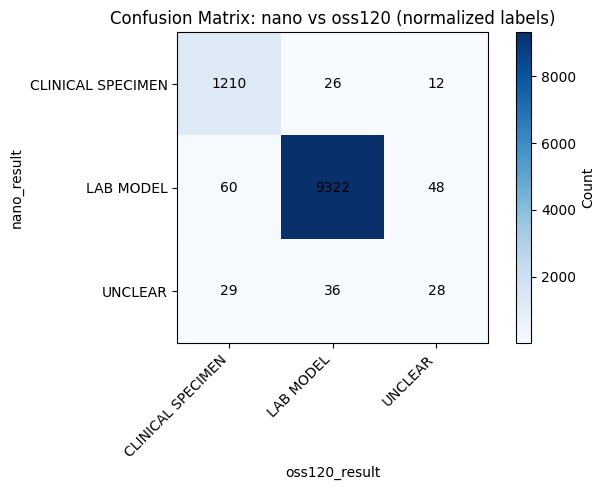

nano_result
LAB MODEL            9430
CLINICAL SPECIMEN    1248
UNCLEAR                93
Name: count, dtype: int64
oss120_result
LAB MODEL            9384
CLINICAL SPECIMEN    1299
UNCLEAR                88
Name: count, dtype: int64


In [ ]:
# OPTIONAL ANALYSIS: skip this cell and the cells below it on a first run.
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

nano_path = Path("rna_seq_data/transcriptomic-source-classification-results-nano.jsonl")
oss120_path = Path("rna_seq_data/transcriptomic-source-classification-results-oss120.jsonl")
gpt52_path = Path("rna_seq_data/transcriptomic-source-classification-results-5.2.jsonl")


def _normalize_label(label):
    if label is None:
        return None

    value = " ".join(str(label).strip().upper().split())

    if "CLINICAL" in value or "PATIENT" in value or "BIOSPECIMEN" in value:
        return "CLINICAL SPECIMEN"
    if "LAB" in value or "EXPERIMENT" in value or "MODEL" in value:
        return "LAB MODEL"
    if "UNCLEAR" in value or "INSUFFICIENT" in value or "VAGUE" in value:
        return "UNCLEAR"

    return value


def _load_classifications(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = item.get("gseid")
            classification = _normalize_label((item.get("response") or {}).get("classification"))
            if gseid:
                records[str(gseid).strip()] = classification
    return records


nano_results = _load_classifications(nano_path)
oss120_results = _load_classifications(oss120_path)

all_gseids = sorted(set(nano_results) | set(oss120_results))
df_results = pd.DataFrame(
    {
        "gseid": all_gseids,
        "nano_result": [nano_results.get(gseid) for gseid in all_gseids],
        "oss120_result": [oss120_results.get(gseid) for gseid in all_gseids],
    }
)

cm = pd.crosstab(
    df_results["nano_result"].fillna("MISSING"),
    df_results["oss120_result"].fillna("MISSING"),
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_title("Confusion Matrix: nano vs oss120 (normalized labels)")
ax.set_xlabel("oss120_result")
ax.set_ylabel("nano_result")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


print(df_results['nano_result'].value_counts())
print(df_results['oss120_result'].value_counts())

In [7]:

mismatch = df_results["nano_result"] != df_results["oss120_result"]
# mismatch_count = mismatch.sum()
# print(f"Number of gseids where normalized nano_result != normalized oss120_result: {mismatch_count}")

mismatch_gseids = set(df_results.loc[mismatch, "gseid"].tolist())
unclear_gseids = set(df_results.loc[(df_results["nano_result"] == "UNCLEAR") | (df_results["oss120_result"] == "UNCLEAR"), "gseid"].tolist())

print(f"Number of gseids where normalized nano_result != normalized oss120_result: {len(mismatch_gseids)}")
print(f"Number of gseids where either nano_result or oss120_result is UNCLEAR: {len(unclear_gseids)}")

total_gseids = mismatch_gseids | unclear_gseids
print("Total number of gseids:", len((total_gseids)))



Number of gseids where normalized nano_result != normalized oss120_result: 211
Number of gseids where either nano_result or oss120_result is UNCLEAR: 153
Total number of gseids: 239


In [15]:
gpt52_results = _load_classifications(gpt52_path)

# Keep agreement labels by default.
df_final = df_results.copy()
df_final["final_label"] = df_final["oss120_result"]

# Replace the 239 mismatch/UNCLEAR gseids with GPT-5.2 labels.
update_mask = df_final["gseid"].isin(total_gseids)
df_final.loc[update_mask, "final_label"] = df_final.loc[update_mask, "gseid"].map(gpt52_results)

missing_updates = sorted(g for g in total_gseids if g not in gpt52_results)
if missing_updates:
    print(f"Warning: GPT-5.2 labels missing for {len(missing_updates)} gseids")

final_counts = df_final["final_label"].value_counts(dropna=False)
final_pct = (final_counts / len(df_final) * 100).round(2)

print(f"Total gseids: {len(df_final)}")
print(f"Updated with GPT-5.2: {int(update_mask.sum())}")
print("\nFinal label distribution (after GPT-5.2 updates):")
print(final_counts)
print("\nFinal label distribution (%):")
print(final_pct)


df_final[df_final['final_label'] == 'CLINICAL SPECIMEN']['gseid'].to_csv('rna_seq_data/clinical_specimen_gseids.csv', index=False)

Total gseids: 10771
Updated with GPT-5.2: 239

Final label distribution (after GPT-5.2 updates):
final_label
LAB MODEL            9483
CLINICAL SPECIMEN    1242
UNCLEAR                46
Name: count, dtype: int64

Final label distribution (%):
final_label
LAB MODEL            88.04
CLINICAL SPECIMEN    11.53
UNCLEAR               0.43
Name: count, dtype: float64


In [ ]:
# 